# 01. 탐색적 데이터 분석 (EDA) - Colab 버전

## 목적
정규화된 레시피 데이터의 품질 검증 및 탐색적 분석

## 분석 항목
1. 데이터 품질 검증
2. 재료 빈도 분포 (Zipf's Law)
3. 재료 공출현 네트워크
4. 재료 클러스터 분석

## 입력
- `data/processed/recipe_v3/recipes_normalized.pkl`

## 출력
- `data/processed/recipe_v3/eda_summary.json`
- `data/processed/recipe_v3/cooccurrence_graph.pkl`

In [2]:
# [1단계] Colab 환경 설정 및 Drive 마운트
import sys
import os

# Colab 환경 감지
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # 프로젝트 루트 설정 (본인의 Drive 경로에 맞게 수정)
    PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone'
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, f'{PROJECT_ROOT}/notebooks')

    # 한글 폰트 설치
    print("🔤 한글 폰트 설치 중...")
    import subprocess
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], capture_output=True)

    print(f"✅ Colab 환경 감지")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")
else:
    from pathlib import Path
    PROJECT_ROOT = Path().resolve().parent
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

    print("💻 로컬 환경에서 실행 중")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔤 한글 폰트 설치 중...
✅ Colab 환경 감지
📁 프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone


In [3]:
# [2단계] 라이브러리 임포트
import pickle
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Colab에서는 문자열을 Path로 변환
if IN_COLAB:
    PROJECT_ROOT = Path(PROJECT_ROOT)
    # 한글 폰트 설정
    import matplotlib.font_manager as fm
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'recipe_v3'

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"데이터 디렉토리: {DATA_DIR}")

프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone
데이터 디렉토리: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3


In [4]:
# 데이터 로드 (Pickle 형식)
df = pd.read_pickle(DATA_DIR / 'recipes_normalized.pkl')
print(f"레시피 수: {len(df):,}")
print(f"컬럼: {df.columns.tolist()}")
df.head()

레시피 수: 202,181
컬럼: ['recipe_id', 'recipe_name', 'ingredients', 'num_ingredients']


,recipe_id,recipe_name,ingredients,num_ingredients
0,7016813,멸치육수 소고기 떡국 만드는법,"[떡국떡g, 소고기g, 멸치육수ml, 파, 계란개, 참기름...",10
1,7016814,#수육용삼겹살 #된장수육만들기 #일상먹거리 #무생채와함께먹는된장수육,"[돼지고기, 된장큰술]",2
2,7016815,우거지감자탕 뼈해장국 끓이는법,"[돼지고기, 양파개, 감자, 파, 배추, 고추, 고추장T, 마늘T,...",14
3,7016816,만두전골 레시피 백종원 만두 전골요리 뜨끈하고 진한 국물이 일품,"[만두개, 배추, 양파개, 파, 버섯, 고추, 다시마개, 고추가루,...",12
4,7016817,새해 통삼겹살 무수분 보쌈 삶는법 백종원 보쌈 마늘소스 만들기,"[돼지고기, 양파개, 파, 마늘개, 강가루, 후추, 설탕T, ...",10


## 1. 데이터 품질 검증

In [5]:
class DataQualityChecker:
    """데이터 품질 검증기"""

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.recipes = df['ingredients'].tolist()

    def check_missing(self) -> Dict:
        """결측치 검사"""
        return {
            col: self.df[col].isna().sum()
            for col in self.df.columns
        }

    def check_duplicates(self) -> int:
        """중복 레시피 검사"""
        # 재료 세트로 변환하여 비교
        recipe_sets = [frozenset(r) for r in self.recipes]
        return len(recipe_sets) - len(set(recipe_sets))

    def get_length_stats(self) -> Dict:
        """재료 수 통계"""
        lengths = [len(r) for r in self.recipes]
        return {
            'mean': np.mean(lengths),
            'median': np.median(lengths),
            'std': np.std(lengths),
            'min': min(lengths),
            'max': max(lengths),
            'q25': np.percentile(lengths, 25),
            'q75': np.percentile(lengths, 75)
        }

    def get_full_report(self) -> Dict:
        """전체 품질 보고서"""
        return {
            'total_recipes': len(self.recipes),
            'missing_values': self.check_missing(),
            'duplicate_recipes': self.check_duplicates(),
            'length_stats': self.get_length_stats()
        }

In [6]:
# 품질 검증 실행
checker = DataQualityChecker(df)
report = checker.get_full_report()

print("=== 데이터 품질 보고서 ===")
print(f"\n총 레시피 수: {report['total_recipes']:,}")
print(f"\n결측치:")
for col, count in report['missing_values'].items():
    print(f"  - {col}: {count}")
print(f"\n중복 레시피: {report['duplicate_recipes']}")
print(f"\n재료 수 통계:")
for stat, val in report['length_stats'].items():
    print(f"  - {stat}: {val:.2f}")

=== 데이터 품질 보고서 ===

총 레시피 수: 202,181

결측치:
  - recipe_id: 0
  - recipe_name: 0
  - ingredients: 0
  - num_ingredients: 0

중복 레시피: 8264

재료 수 통계:
  - mean: 7.78
  - median: 7.00
  - std: 3.39
  - min: 2.00
  - max: 43.00
  - q25: 5.00
  - q75: 10.00


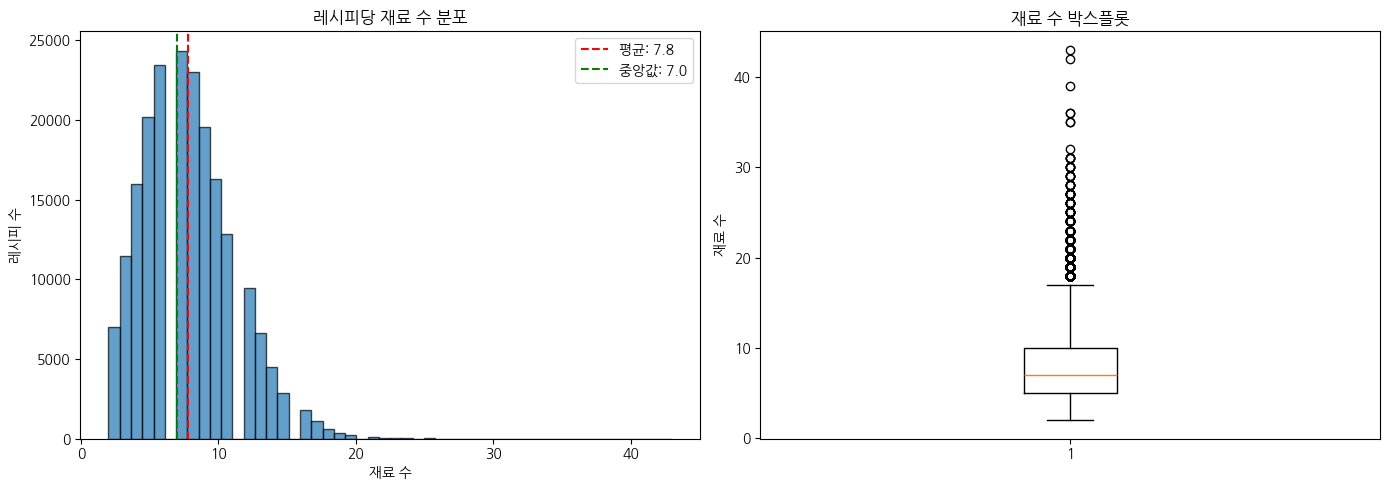

In [7]:
# 재료 수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lengths = [len(r) for r in df['ingredients']]

# 히스토그램
axes[0].hist(lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(lengths), color='red', linestyle='--', label=f'평균: {np.mean(lengths):.1f}')
axes[0].axvline(np.median(lengths), color='green', linestyle='--', label=f'중앙값: {np.median(lengths):.1f}')
axes[0].set_xlabel('재료 수')
axes[0].set_ylabel('레시피 수')
axes[0].set_title('레시피당 재료 수 분포')
axes[0].legend()

# 박스플롯
axes[1].boxplot(lengths, vert=True)
axes[1].set_ylabel('재료 수')
axes[1].set_title('재료 수 박스플롯')

plt.tight_layout()
plt.savefig(DATA_DIR / 'ingredient_count_distribution.png', dpi=150)
plt.show()

## 2. 재료 빈도 분석 (Zipf's Law)

In [8]:
# 재료 빈도 계산
ingredient_counter = Counter()
for recipe in df['ingredients']:
    ingredient_counter.update(recipe)

print(f"총 고유 재료 수: {len(ingredient_counter):,}")
print(f"\n상위 30개 재료:")
for rank, (ing, count) in enumerate(ingredient_counter.most_common(30), 1):
    pct = count / len(df) * 100
    print(f"  {rank:2d}. {ing}: {count:,}회 ({pct:.1f}%)")

총 고유 재료 수: 12,132

상위 30개 재료:
   1. 파: 66,587회 (32.9%)
   2. 마늘: 61,389회 (30.4%)
   3. 양파: 51,695회 (25.6%)
   4. 간장: 51,490회 (25.5%)
   5. 설탕: 47,337회 (23.4%)
   6. 고추가루: 45,558회 (22.5%)
   7. 고추: 45,287회 (22.4%)
   8. 소금: 45,021회 (22.3%)
   9. 계란: 39,053회 (19.3%)
  10. 후추: 38,218회 (18.9%)
  11. 참기름: 35,576회 (17.6%)
  12. 생크림: 29,227회 (14.5%)
  13. 버섯: 22,584회 (11.2%)
  14. 식용유: 20,751회 (10.3%)
  15. 당근: 20,474회 (10.1%)
  16. 통깨: 20,186회 (10.0%)
  17. 생선: 18,731회 (9.3%)
  18. 조개: 18,001회 (8.9%)
  19. 돼지고기: 16,652회 (8.2%)
  20. 감자: 15,753회 (7.8%)
  21. 맛술: 14,757회 (7.3%)
  22. 올리고당: 13,901회 (6.9%)
  23. 소고기: 13,861회 (6.9%)
  24. 치즈: 13,559회 (6.7%)
  25. 배추: 12,769회 (6.3%)
  26. 식초: 12,264회 (6.1%)
  27. 고구마: 11,756회 (5.8%)
  28. 버터: 11,723회 (5.8%)
  29. 무: 11,001회 (5.4%)
  30. 올리브유: 10,305회 (5.1%)


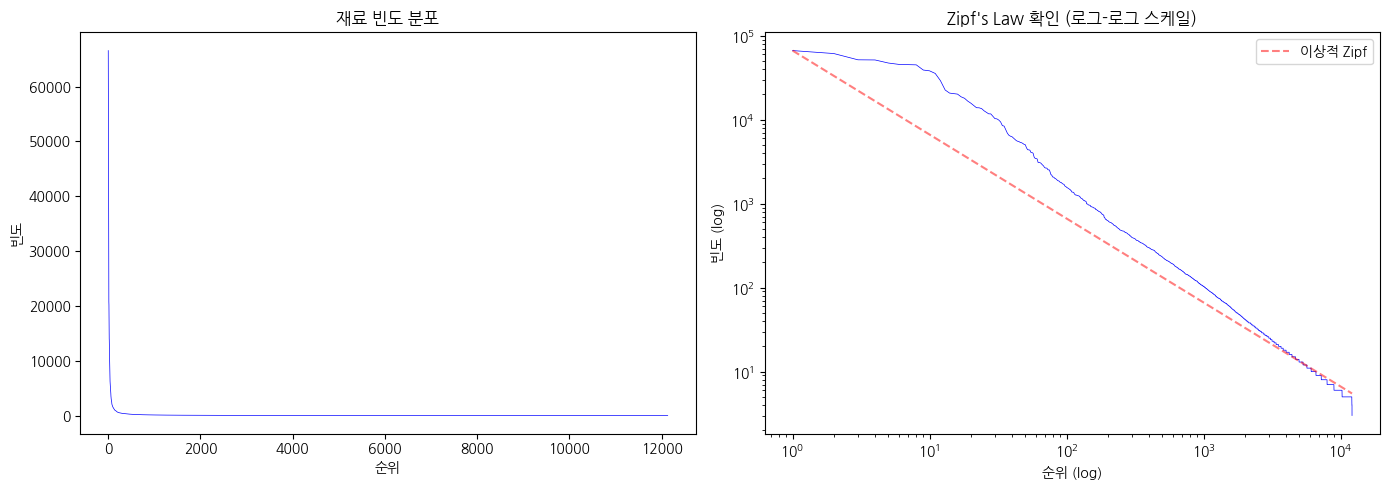

In [9]:
# Zipf's Law 시각화
frequencies = sorted(ingredient_counter.values(), reverse=True)
ranks = range(1, len(frequencies) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 순위-빈도 그래프
axes[0].plot(ranks, frequencies, 'b-', linewidth=0.5)
axes[0].set_xlabel('순위')
axes[0].set_ylabel('빈도')
axes[0].set_title('재료 빈도 분포')

# 로그-로그 스케일 (Zipf's Law 확인)
axes[1].loglog(ranks, frequencies, 'b-', linewidth=0.5)
axes[1].set_xlabel('순위 (log)')
axes[1].set_ylabel('빈도 (log)')
axes[1].set_title('Zipf\'s Law 확인 (로그-로그 스케일)')

# 이상적인 Zipf 분포 추가
ideal_zipf = [frequencies[0] / r for r in ranks]
axes[1].loglog(ranks, ideal_zipf, 'r--', alpha=0.5, label='이상적 Zipf')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'zipf_distribution.png', dpi=150)
plt.show()

In [10]:
# Head / Torso / Tail 분석
def analyze_frequency_distribution(counter: Counter, thresholds: Dict[str, int]) -> Dict:
    """빈도 구간별 분석"""
    head_thresh = thresholds.get('head', 1000)
    torso_thresh = thresholds.get('torso', 100)

    head = {ing: cnt for ing, cnt in counter.items() if cnt >= head_thresh}
    torso = {ing: cnt for ing, cnt in counter.items() if torso_thresh <= cnt < head_thresh}
    tail = {ing: cnt for ing, cnt in counter.items() if cnt < torso_thresh}

    return {
        'head': {'count': len(head), 'ingredients': list(head.keys())},
        'torso': {'count': len(torso), 'ingredients': list(torso.keys())},
        'tail': {'count': len(tail), 'ingredients': list(tail.keys())}
    }

freq_dist = analyze_frequency_distribution(ingredient_counter, {'head': 1000, 'torso': 100})

print("=== 빈도 구간별 분석 ===")
total = len(ingredient_counter)
for segment, data in freq_dist.items():
    pct = data['count'] / total * 100
    print(f"\n{segment.upper()}:")
    print(f"  - 재료 수: {data['count']:,} ({pct:.1f}%)")
    if segment == 'head':
        print(f"  - 예시: {data['ingredients'][:10]}")

=== 빈도 구간별 분석 ===

HEAD:
  - 재료 수: 139 (1.1%)
  - 예시: ['파', '계란\x07\x07개\x07', '참기름\x07\x07T\x07', '간장', '돼지고기', '양파\x07\x07개\x07', '감자', '배추', '고추', '마늘\x07\x07T\x07']

TORSO:
  - 재료 수: 894 (7.4%)

TAIL:
  - 재료 수: 11,099 (91.5%)


## 3. 재료 공출현 네트워크

In [11]:
# NetworkX 설치 확인 및 임포트
try:
    import networkx as nx
    print(f"NetworkX 버전: {nx.__version__}")
except ImportError:
    print("NetworkX 설치 중...")
    !pip install networkx
    import networkx as nx

NetworkX 버전: 3.6.1


In [12]:
def build_cooccurrence_graph(
    recipes: List[List[str]],
    min_cooccurrence: int = 50,
    top_n_ingredients: int = 200
) -> nx.Graph:
    """재료 공출현 네트워크 구축

    Args:
        recipes: 레시피 리스트
        min_cooccurrence: 최소 공출현 횟수
        top_n_ingredients: 상위 N개 재료만 사용

    Returns:
        NetworkX 그래프
    """
    # 상위 재료 필터링
    counter = Counter()
    for recipe in recipes:
        counter.update(recipe)

    top_ingredients = set(
        ing for ing, _ in counter.most_common(top_n_ingredients)
    )

    # 공출현 계산
    cooccurrence = defaultdict(int)
    for recipe in recipes:
        filtered = [ing for ing in recipe if ing in top_ingredients]
        for ing1, ing2 in combinations(sorted(filtered), 2):
            cooccurrence[(ing1, ing2)] += 1

    # 그래프 구축
    G = nx.Graph()

    for (ing1, ing2), count in cooccurrence.items():
        if count >= min_cooccurrence:
            G.add_edge(ing1, ing2, weight=count)

    # 노드 속성 추가
    for node in G.nodes():
        G.nodes[node]['frequency'] = counter[node]

    return G

In [13]:
# 공출현 네트워크 구축
print("공출현 네트워크 구축 중...")
G = build_cooccurrence_graph(
    df['ingredients'].tolist(),
    min_cooccurrence=100,
    top_n_ingredients=150
)

print(f"\n=== 네트워크 통계 ===")
print(f"노드 수 (재료): {G.number_of_nodes()}")
print(f"엣지 수 (공출현): {G.number_of_edges()}")
print(f"평균 차수: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"밀도: {nx.density(G):.4f}")

공출현 네트워크 구축 중...

=== 네트워크 통계 ===
노드 수 (재료): 150
엣지 수 (공출현): 3602
평균 차수: 48.03
밀도: 0.3223


In [14]:
# 중심성 분석
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

print("\n=== 중심성 상위 재료 (Degree Centrality) ===")
for ing, cent in sorted(degree_centrality.items(), key=lambda x: -x[1])[:15]:
    print(f"  {ing}: {cent:.4f}")

print("\n=== 매개 중심성 상위 재료 (Betweenness) ===")
for ing, cent in sorted(betweenness.items(), key=lambda x: -x[1])[:15]:
    print(f"  {ing}: {cent:.4f}")


=== 중심성 상위 재료 (Degree Centrality) ===
  간장: 0.9396
  파: 0.9329
  고추: 0.9329
  소금: 0.8926
  고추가루: 0.8792
  버섯: 0.8792
  계란: 0.8725
  후추: 0.8658
  설탕: 0.8456
  양파: 0.8389
  마늘: 0.8322
  생크림: 0.8322
  조개: 0.7987
  생선: 0.7852
  식용유: 0.7785

=== 매개 중심성 상위 재료 (Betweenness) ===
  간장: 0.0463
  파: 0.0426
  고추: 0.0426
  소금: 0.0393
  계란: 0.0379
  고추가루: 0.0357
  버섯: 0.0344
  설탕: 0.0308
  생크림: 0.0294
  후추: 0.0291
  생선: 0.0267
  조개: 0.0259
  양파: 0.0239
  마늘: 0.0229
  식용유: 0.0203


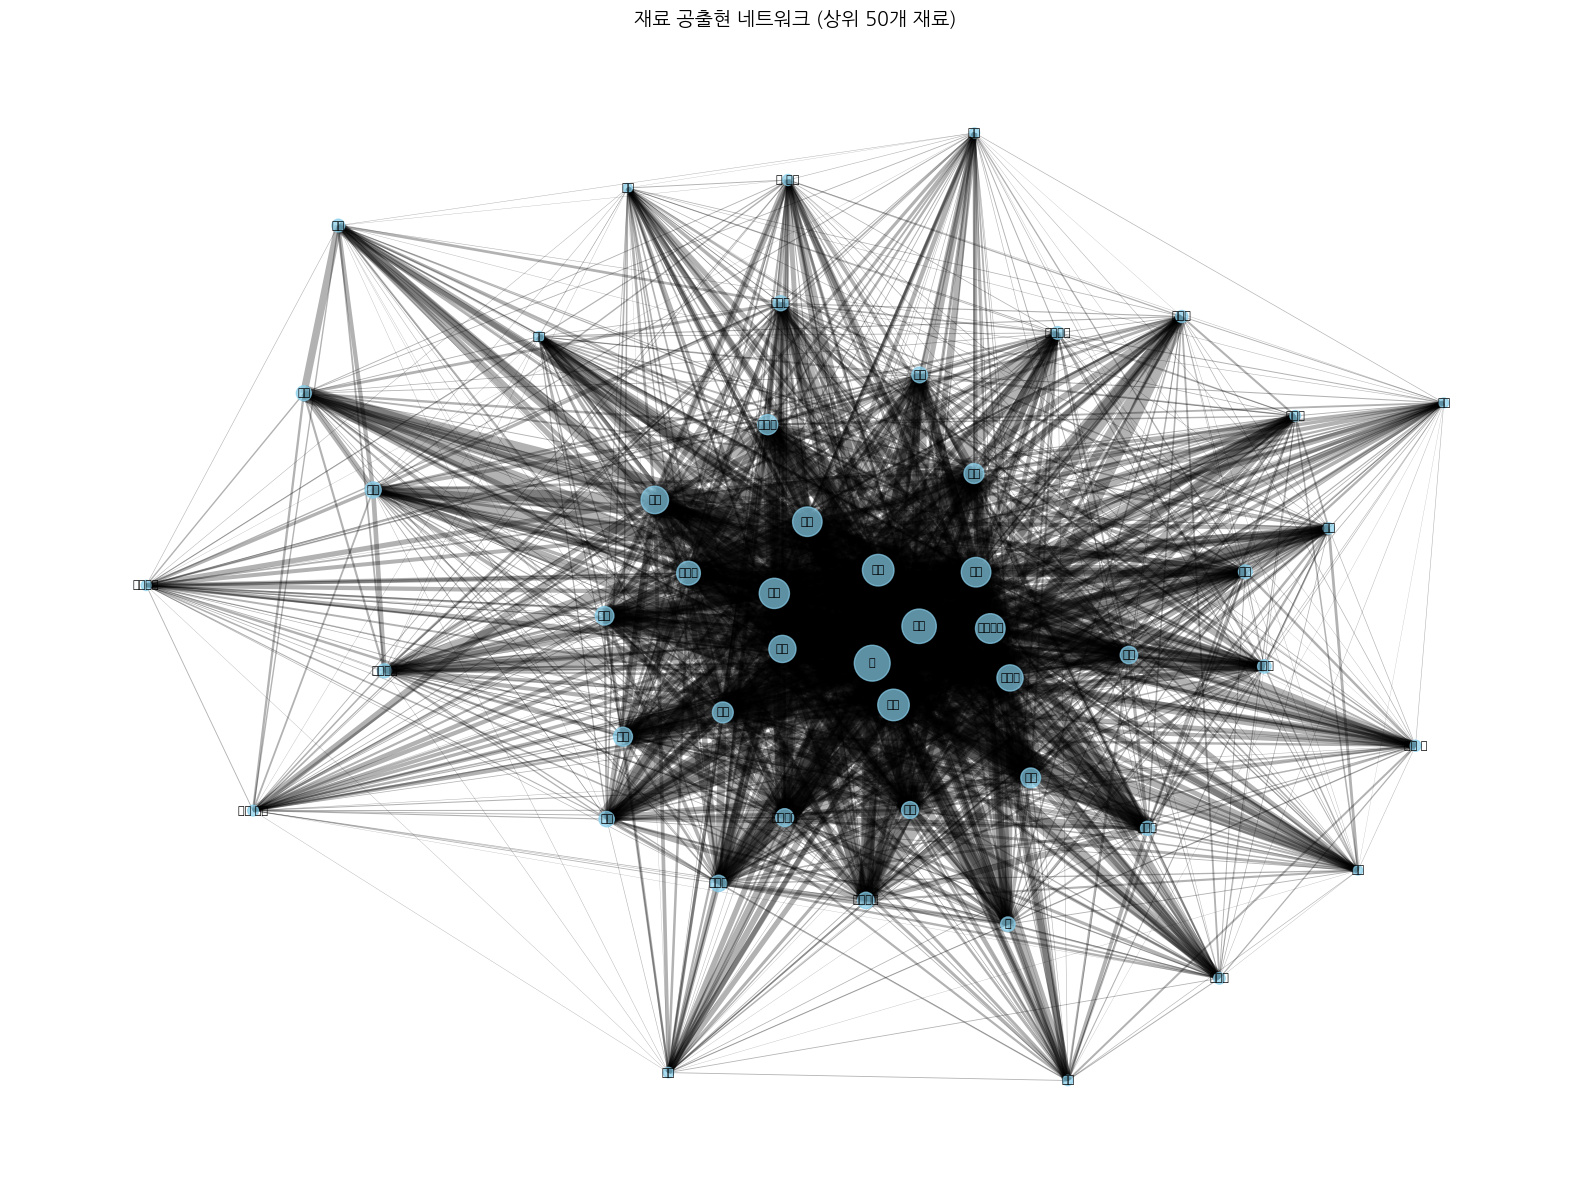

In [15]:
# 네트워크 시각화 (상위 연결 재료만)
top_nodes = sorted(degree_centrality.items(), key=lambda x: -x[1])[:50]
top_node_set = set(n for n, _ in top_nodes)
G_sub = G.subgraph(top_node_set)

plt.figure(figsize=(16, 12))

# 레이아웃
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

# 노드 크기 (빈도 기반)
node_sizes = [G_sub.nodes[n].get('frequency', 100) / 100 for n in G_sub.nodes()]

# 엣지 두께 (가중치 기반)
edge_weights = [G_sub[u][v]['weight'] / 500 for u, v in G_sub.edges()]

# 그리기
nx.draw_networkx_edges(G_sub, pos, alpha=0.3, width=edge_weights)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, alpha=0.7, node_color='skyblue')
nx.draw_networkx_labels(G_sub, pos, font_size=8, font_family='Malgun Gothic')

plt.title('재료 공출현 네트워크 (상위 50개 재료)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cooccurrence_network.png', dpi=150)
plt.show()

## 4. 커뮤니티 탐지 (재료 클러스터)

In [16]:
# Louvain 커뮤니티 탐지
try:
    from community import community_louvain
except ImportError:
    print("python-louvain 설치 중...")
    %pip install python-louvain
    from community import community_louvain

In [17]:
# 커뮤니티 탐지
partition = community_louvain.best_partition(G)
n_communities = max(partition.values()) + 1

print(f"탐지된 커뮤니티 수: {n_communities}")

# 커뮤니티별 재료 그룹화
communities = defaultdict(list)
for node, comm_id in partition.items():
    communities[comm_id].append(node)

print("\n=== 커뮤니티별 재료 ===")
for comm_id in sorted(communities.keys()):
    members = communities[comm_id]
    # 빈도순 정렬
    members_sorted = sorted(members, key=lambda x: -ingredient_counter[x])
    print(f"\n커뮤니티 {comm_id} ({len(members)}개 재료):")
    print(f"  대표 재료: {members_sorted[:8]}")

탐지된 커뮤니티 수: 4

=== 커뮤니티별 재료 ===

커뮤니티 0 (55개 재료):
  대표 재료: ['파', '마늘', '간장', '고추가루', '고추', '참기름', '통깨', '생선']

커뮤니티 1 (48개 재료):
  대표 재료: ['설탕', '소금', '계란', '생크림', '식용유', '치즈', '고구마', '버터']

커뮤니티 2 (33개 재료):
  대표 재료: ['양파', '후추', '버섯', '당근', '조개', '돼지고기', '감자', '배추']

커뮤니티 3 (14개 재료):
  대표 재료: ['양파\x07\x07개\x07', '계란\x07\x07개\x07', '마늘\x07\x07큰술\x07', '마늘\x07\x07T\x07', '물\x07\x07ml\x07', '설탕\x07\x07T\x07', '참기름\x07\x07큰술\x07', '참기름\x07\x07T\x07']


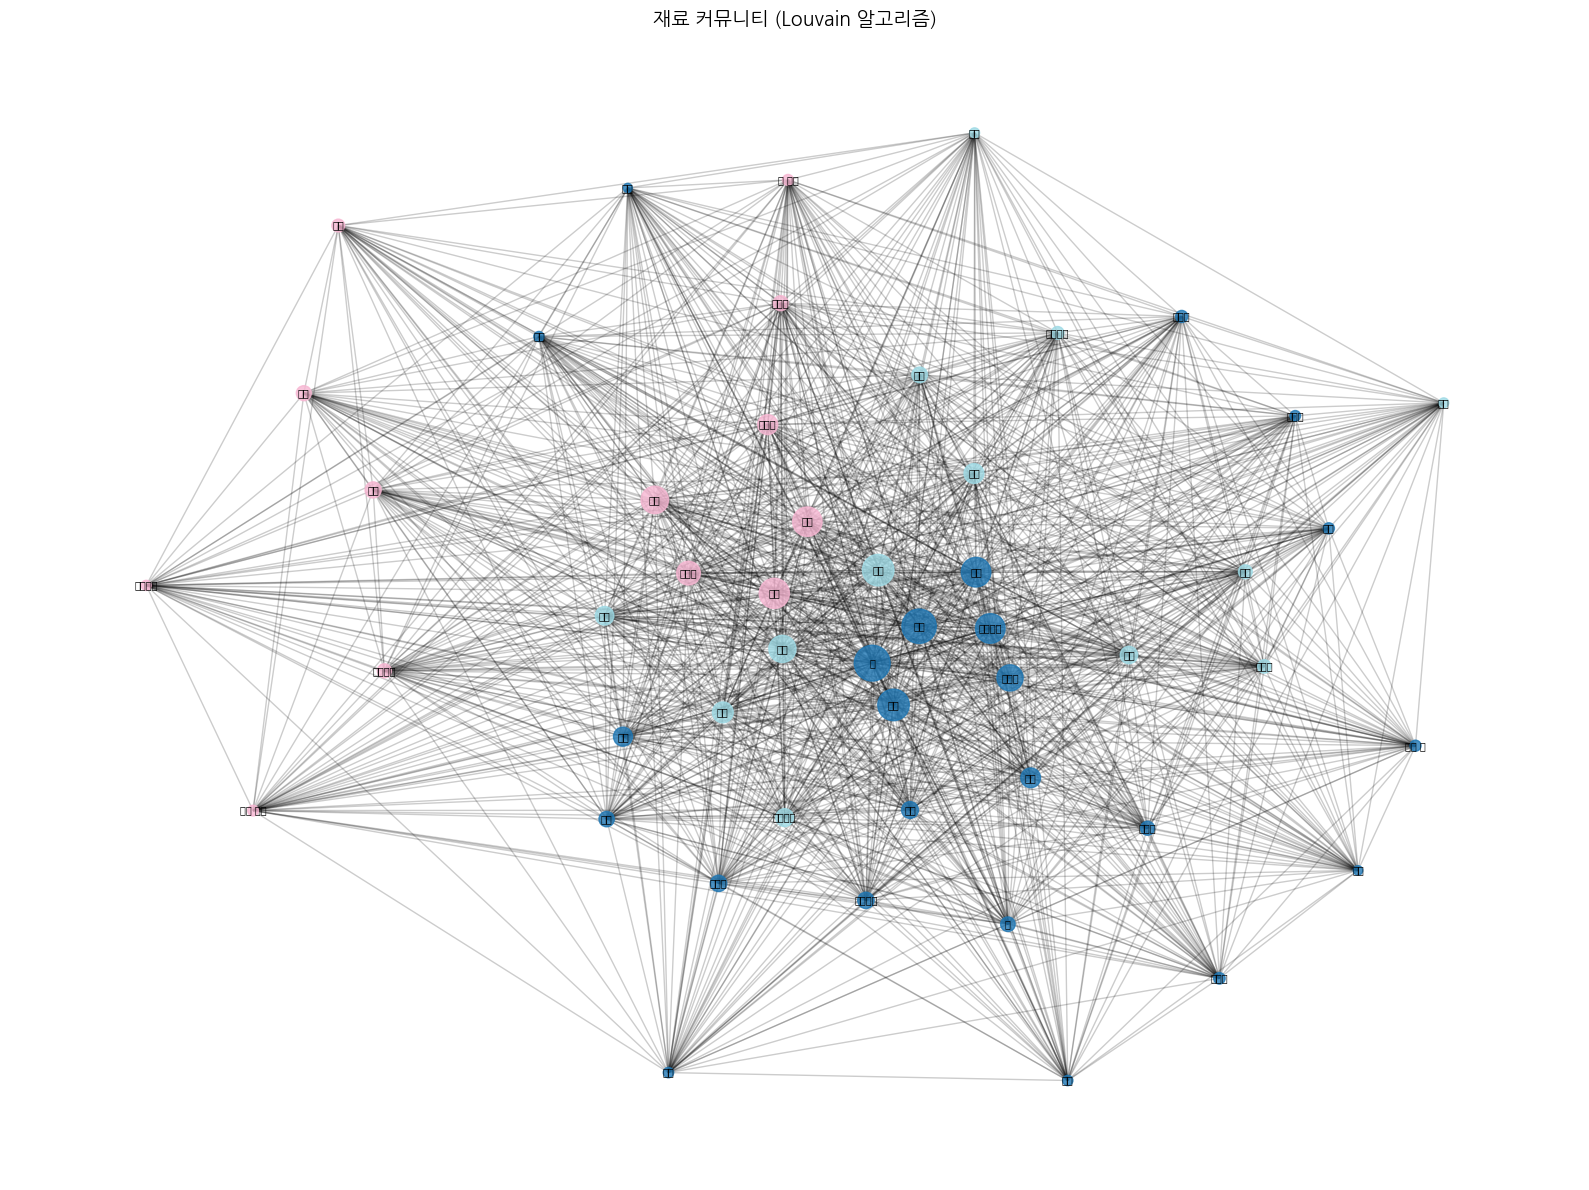

In [18]:
# 커뮤니티 시각화
plt.figure(figsize=(16, 12))

# 커뮤니티별 색상
colors = [partition[node] for node in G_sub.nodes()]
cmap = plt.cm.get_cmap('tab20', n_communities)

nx.draw_networkx_edges(G_sub, pos, alpha=0.2)
nx.draw_networkx_nodes(
    G_sub, pos,
    node_size=node_sizes,
    node_color=colors,
    cmap=cmap,
    alpha=0.8
)
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_family='Malgun Gothic')

plt.title('재료 커뮤니티 (Louvain 알고리즘)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR / 'ingredient_communities.png', dpi=150)
plt.show()

## 5. 결과 저장

In [19]:
# 네트워크 그래프 저장 (pickle 사용)
graph_path = DATA_DIR / 'cooccurrence_graph.pkl'
with open(graph_path, 'wb') as f:
    pickle.dump(G, f)
print(f"네트워크 그래프 저장: {graph_path}")

네트워크 그래프 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/cooccurrence_graph.pkl


In [20]:
# EDA 결과 요약
eda_summary = {
    'total_recipes': len(df),
    'total_ingredients': len(ingredient_counter),
    'avg_ingredients_per_recipe': np.mean([len(r) for r in df['ingredients']]),
    'network_nodes': G.number_of_nodes(),
    'network_edges': G.number_of_edges(),
    'num_communities': n_communities,
    'top_10_ingredients': [ing for ing, _ in ingredient_counter.most_common(10)],
    'frequency_distribution': {
        'head': freq_dist['head']['count'],
        'torso': freq_dist['torso']['count'],
        'tail': freq_dist['tail']['count']
    }
}

import json
with open(DATA_DIR / 'eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)

print("\n=== EDA 요약 ===")
for key, val in eda_summary.items():
    print(f"{key}: {val}")


=== EDA 요약 ===
total_recipes: 202181
total_ingredients: 12132
avg_ingredients_per_recipe: 7.780736073122598
network_nodes: 150
network_edges: 3602
num_communities: 4
top_10_ingredients: ['파', '마늘', '양파', '간장', '설탕', '고추가루', '고추', '소금', '계란', '후추']
frequency_distribution: {'head': 139, 'torso': 894, 'tail': 11099}


In [21]:
print("\n" + "="*50)
print("EDA 완료")
print("="*50)
print(f"\n생성된 파일:")
print(f"  - {DATA_DIR / 'ingredient_count_distribution.png'}")
print(f"  - {DATA_DIR / 'zipf_distribution.png'}")
print(f"  - {DATA_DIR / 'cooccurrence_network.png'}")
print(f"  - {DATA_DIR / 'ingredient_communities.png'}")
print(f"  - {DATA_DIR / 'cooccurrence_graph.pkl'}")
print(f"  - {DATA_DIR / 'eda_summary.json'}")


EDA 완료

생성된 파일:
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/ingredient_count_distribution.png
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/zipf_distribution.png
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/cooccurrence_network.png
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/ingredient_communities.png
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/cooccurrence_graph.pkl
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/eda_summary.json
